In [1]:
# Part 1: Data Preprocessing and Integration
# This part of the code is for reference. It cleans and merges the original data files.
# NOTE: This block cannot be re-run in the current environment due to the absence of the 'mygene' library.
# The analysis will proceed from Part 2, which loads the output of this block ('GSE164641_master_dataframe.csv').

import pandas as pd
import mygene
import re

def parse_series_matrix(file_path):
    """
    Parses a GEO series matrix file to extract sample IDs and clinical characteristics.

    Args:
        file_path (str): The path to the series matrix file.

    Returns:
        pd.DataFrame: A DataFrame containing clinical data with sample IDs.
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # Get sample IDs (GSMs)
    sample_ids = []
    for line in lines:
        if line.startswith("!Sample_geo_accession"):
            sample_ids = line.strip().split('\t')[1:]
            sample_ids = [s.replace('"', '') for s in sample_ids]
            break

    # Obtain feature categories
    characteristics = {}
    for line in lines:
        if line.startswith("!Sample_characteristics_ch1"):
            parts = line.strip().split('\t')
            if len(parts) < 2:
                continue

            first_value_cell = parts[1].replace('"', '')
            if ':' not in first_value_cell:
                continue

            feature_name_raw = first_value_cell.split(':')[0]
            feature_name = feature_name_raw.strip().replace(' ', '_').lower()

            prefix_to_remove = f"{feature_name_raw}: "
            values = [v.replace('"', '') for v in parts[1:]]
            cleaned_values = [v.replace(prefix_to_remove, "").strip() for v in values]

            characteristics[feature_name] = cleaned_values

    # Create a DataFrame for clinical data
    clinical_df = pd.DataFrame(characteristics)
    clinical_df.insert(0, 'sample_id', sample_ids)

    return clinical_df

def load_gene_id_map(annot_file_path):
    """
    Loads gene ID to symbol mapping from the local annotation TSV file.
    
    Args:
        annot_file_path (str): Path to 'Human.GRCh38.p13.annot.tsv'
        
    Returns:
        dict: A dictionary mapping gene IDs (col 0) to gene symbols (col 1).
    """
    print(f"Loading gene annotations from {annot_file_path}...")
    annot_df = pd.read_csv(
        annot_file_path, 
        sep='\t', 
        header=None, 
        usecols=[0, 1],
        on_bad_lines='skip', low_memory=False
    )

    annot_df.columns = ['gene_id', 'gene_symbol']

    annot_df.dropna(subset=['gene_id', 'gene_symbol'], inplace=True)

    id_to_symbol_map = dict(zip(annot_df['gene_id'].astype(str), annot_df['gene_symbol']))
    
    print(f"Successfully created mapping for {len(id_to_symbol_map)} genes.")
    return id_to_symbol_map

# --- Main Data Integration Workflow ---

# 1. Parse clinical data from the series matrix file
clinical_df = parse_series_matrix('GSE164641_series_matrix.txt')

# Rename columns for clarity and consistency
if 'life_time_risk_(tyrer-cuzick_score)' in clinical_df.columns:
    clinical_df.rename(columns={'life_time_risk_(tyrer-cuzick_score)': 'tyrer_cuzick_score'}, inplace=True)
if 'risk_category' in clinical_df.columns:
    clinical_df.rename(columns={'risk_category': 'target'}, inplace=True)

# 2. Load and transpose raw gene counts data
raw_counts_df = pd.read_csv('GSE164641_raw_counts_GRCh38.p13_NCBI.tsv', sep='\t', index_col=0)
raw_counts_df = raw_counts_df.T
raw_counts_df.reset_index(inplace=True)
raw_counts_df.rename(columns={'index': 'sample_id'}, inplace=True)

# 3. Map gene IDs to gene symbols using the local annotation file
raw_counts_df.columns = raw_counts_df.columns.map(str)
gene_columns = raw_counts_df.columns[1:] 

gene_id_map = load_gene_id_map('Human.GRCh38.p13.annot.tsv') 

if gene_id_map:
    raw_counts_df = raw_counts_df.rename(columns=gene_id_map)
    print("Gene IDs successfully mapped to symbols.")
else:
    print("Warning: Gene ID mapping failed. Columns will remain as IDs.")

# 4. Merge clinical and expression data, then save to CSV
master_df = pd.merge(clinical_df, raw_counts_df, on='sample_id', how='inner')
master_df.set_index('sample_id', inplace=True)
master_df.to_csv('GSE164641_master_dataframe.csv')

print("\nMaster DataFrame created and saved to 'GSE164641_master_dataframe.csv'")

Loading gene annotations from Human.GRCh38.p13.annot.tsv...
Successfully created mapping for 39377 genes.
Gene IDs successfully mapped to symbols.

Master DataFrame created and saved to 'GSE164641_master_dataframe.csv'


In [2]:
# --- Import necessary libraries for this section ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import warnings
# --- Data Preparation & Train/Test Split (NEW) ---
from sklearn.model_selection import train_test_split

# --- Suppress warnings for cleaner output ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# --- Global Plotting Style Setup ---
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.titlesize': 20,
    'axes.labelsize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 14,
    'figure.titlesize': 22,
})

from pathlib import Path
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _savefig(filename: str, dpi: int = 300):
    """Save current matplotlib figure into output/ with tight layout."""
    fp = OUT_DIR / filename
    plt.savefig(fp, dpi=dpi, bbox_inches="tight")
    print(f"[saved] {fp}")

print("--- Loading and Splitting Data ---")
# 1. Load the original master data
raw_master_df = pd.read_csv('GSE164641_master_dataframe.csv', index_col=0, low_memory=False)

# 2. Extract labels for stratified sampling
y_temp = raw_master_df['target'].map({'High': 1, 'Average': 0})

# 3. Perform an 80/20 split (set `random_state=42` to ensure reproducible results)
df_train_80, df_test_20 = train_test_split(
    raw_master_df, 
    test_size=0.20, 
    stratify=y_temp, 
    random_state=42
)

# 4. Save the split datasets separately
df_train_80.to_csv('GSE164641_train_80.csv')
df_test_20.to_csv('GSE164641_test_20.csv')
print(f"Data split successful!")
print(f"Train (80%) shape: {df_train_80.shape}")
print(f"Test (20%) shape: {df_test_20.shape}")

--- Loading and Splitting Data ---
Data split successful!
Train (80%) shape: (149, 39388)
Test (20%) shape: (38, 39388)


--- Generating PCA Plot for All Genes (with Confidence Ellipses) ---
[saved] output\pca_all_genes.png


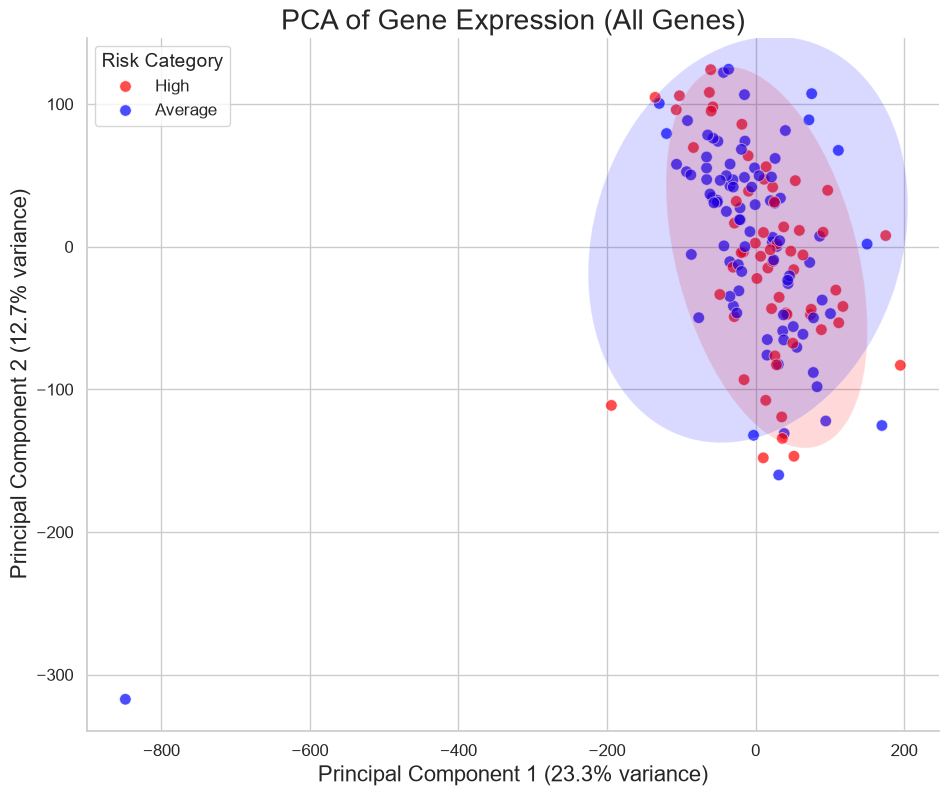

In [3]:
# 5. All subsequent feature selection, PCA, and volcano plots will use only 80% of the training set
master_df = df_train_80.copy()

# Separate features (X) and target (y)
y = master_df['target'].map({'High': 1, 'Average': 0})
X = master_df.drop(columns=['target'])

# Isolate gene expression data by defining and removing clinical/categorical columns
categorical_cols = [
    'age', 'age_of_menarche', 'menopausal_status', 'brca1', 'brca2',
    'blood_relatives_cancer', 'race', 'hispanic', 'bmi', 'ever_pregnant',
    'tyrer_cuzick_score'
]
cat_cols_in_df = [col for col in categorical_cols if col in X.columns]
X_cont_raw = X.drop(columns=cat_cols_in_df)

# Log-transform the gene expression data for PCA and heatmap visualization
# log1p is used to handle counts of 0
X_log_transformed = np.log1p(X_cont_raw)

# --- PCA on All Genes ---
print("--- Generating PCA Plot for All Genes (with Confidence Ellipses) ---")

# Scale the log-transformed data
scaler_global = StandardScaler()
X_log_scaled_global = scaler_global.fit_transform(X_log_transformed)

# Perform PCA
pca_global = PCA(n_components=2)
principal_components_global = pca_global.fit_transform(X_log_scaled_global)

# Create a DataFrame for plotting
pca_df_global = pd.DataFrame(data=principal_components_global, columns=['PC1', 'PC2'], index=X.index)
pca_df_global['Risk Category'] = y.map({1: 'High', 0: 'Average'}).values
variance_explained_global = pca_global.explained_variance_ratio_

# --- Plotting Section with Ellipses ---
plt.figure(figsize=(11, 9))
palette = {'High': 'red', 'Average': 'blue'}

# Create the main scatter plot
ax = sns.scatterplot(
    x='PC1', y='PC2',
    hue='Risk Category',
    data=pca_df_global,
    palette=palette,
    s=70,
    alpha=0.7
)

# Add 95% confidence ellipses for each group
for category in pca_df_global['Risk Category'].unique():
    subset = pca_df_global[pca_df_global['Risk Category'] == category]
    
    # Ensure there are enough points to calculate covariance
    if subset.shape[0] < 2:
        continue
        
    cov = np.cov(subset['PC1'], subset['PC2'])
    center = subset[['PC1', 'PC2']].mean().values
    
    # Check for valid covariance matrix before calculating ellipse properties
    if not (np.any(np.isnan(cov)) or np.any(np.isinf(cov))):
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(*eigenvectors[:,0][::-1]))
            # Calculate width and height for 2 standard deviations (95% confidence)
            width, height = 2 * 2 * np.sqrt(eigenvalues)
            
            ellipse = Ellipse(xy=center, width=width, height=height, angle=angle,
                              facecolor=palette.get(category, 'gray'), alpha=0.15)
            ax.add_patch(ellipse)
        except np.linalg.LinAlgError:
            # This can happen if covariance matrix is not positive semi-definite
            print(f"Could not compute confidence ellipse for '{category}' group.")

# Set plot titles and labels
ax.set_title("PCA of Gene Expression (All Genes)")
ax.set_xlabel(f'Principal Component 1 ({variance_explained_global[0]*100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({variance_explained_global[1]*100:.1f}% variance)')
ax.legend(title='Risk Category')
sns.despine() # Remove the top and right spines
_savefig("pca_all_genes.png")
# Display the plot
plt.show()

In [4]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print("--- Running DESeq2 Differential Expression Analysis ---")

# --- Step 1: Run DESeq2 ---
# The count data (X_cont_raw) and metadata (y) must be properly formatted.
# The metadata needs to be in a DataFrame with a column for the design factor.
samples_df = pd.DataFrame({'condition': y})

# Initialize the DeseqDataSet object
# 'counts' should be a DataFrame of integers (raw counts).
# 'metadata' is the sample information DataFrame.
# 'design_factors' specifies the column in metadata to use for comparison.
dds = DeseqDataSet(
    counts=X_cont_raw,
    metadata=samples_df,
    design='~condition'
)

# Run the full DESeq2 pipeline (normalization, dispersion estimation, fitting)
dds.deseq2()

# --- Step 2: Save Normalized Counts ---
# Extract the normalized counts from the DeseqDataSet object.
# The result is transposed (.T) to have samples as rows and genes as columns.
normalized_counts_df = pd.DataFrame(
    dds.layers['normed_counts'], 
    index=X_cont_raw.index, 
    columns=X_cont_raw.columns
)
normalized_counts_df.to_csv('deseq2_normalized_counts.csv')
print("DESeq2 normalized counts successfully saved to 'deseq2_normalized_counts.csv'")


# --- Step 3: Perform Statistical Analysis ---
# Perform statistical tests to compare conditions.
# The contrast specifies the comparison: 'condition' column, level '1' (High) vs level '0' (Average).
stat_res = DeseqStats(dds, contrast=['condition', 1, 0])

# This runs the statistical analysis and stores the results.
stat_res.summary()
results_df = stat_res.results_df # Get the results as a DataFrame
# Save the full statistical results to a CSV file
results_df.to_csv('deseq2_statistical_results.csv')
print("DESeq2 statistical results saved to 'deseq2_statistical_results.csv'")

# --- Step 4: Filter for Significant Genes ---
# Define thresholds for significance.
padj_thresh = 0.05
log2fc_thresh = 1.0

# Filter the results DataFrame based on the adjusted p-value and log2 fold change.
significant_genes_df = results_df[
    (results_df['padj'] < padj_thresh) &
    (abs(results_df['log2FoldChange']) > log2fc_thresh)
]

# Get the list of significant gene names (from the DataFrame index).
significant_genes = significant_genes_df.index.tolist()

print(f"\nDESeq2 analysis complete.")
print(f"Found {len(significant_genes)} significantly differentially expressed genes.")
print(f"(Using padj < {padj_thresh} and |log2FoldChange| > {log2fc_thresh})")

--- Running DESeq2 Differential Expression Analysis ---
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.12 seconds.

Fitting dispersions...
... done in 1.44 seconds.

Fitting dispersion trend curve...
... done in 0.45 seconds.

Fitting MAP dispersions...
... done in 1.75 seconds.

Fitting LFCs...
... done in 1.58 seconds.

Calculating cook's distance...
... done in 0.23 seconds.

Replacing 2054 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.17 seconds.



DESeq2 normalized counts successfully saved to 'deseq2_normalized_counts.csv'


Running Wald tests...
... done in 1.53 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
                  baseMean  log2FoldChange     lfcSE      stat    pvalue  \
DDX11L1          17.231444       -0.021033  0.150907 -0.139378  0.889151   
WASH7P          576.604948       -0.115613  0.100569 -1.149588  0.250313   
MIR6859-1        20.627934       -0.031033  0.148275 -0.209297  0.834217   
MIR1302-2HG       3.227143        0.494506  0.205174  2.410181  0.015945   
MIR1302-2         0.812432        0.152006  0.301406  0.504323  0.614034   
...                    ...             ...       ...       ...       ...   
ND6           84477.432918       -0.153436  0.111473 -1.376432  0.168688   
TRNE           7497.410518       -0.133824  0.101360 -1.320294  0.186737   
CYTB         323916.182440       -0.119345  0.108820 -1.096725  0.272762   
TRNT            557.726131       -0.485532  0.132357 -3.668364  0.000244   
TRNP           4626.382303        0.149919  0.122838  1.220465  0.222289   

                 padj  
DDX11L1 

--- Visualizing results for 263 significant genes ---

--- Generating PCA Plot for Significant Genes ---
[saved] output\pca_significant_genes.png


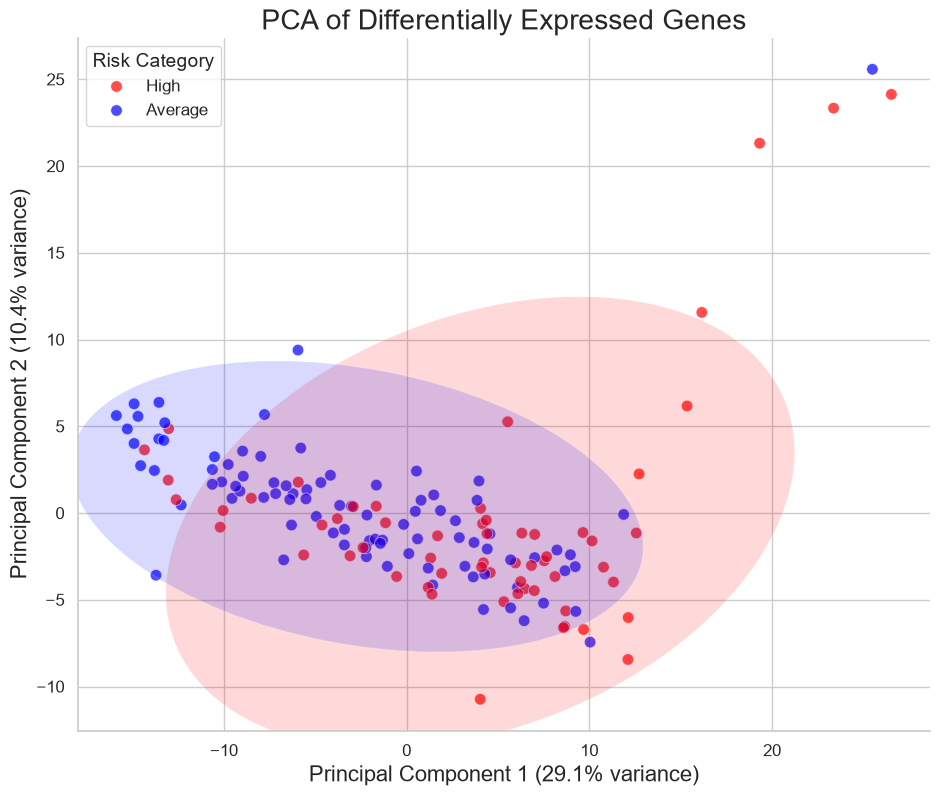

In [5]:
from adjustText import adjust_text
from scipy.stats import zscore

print(f"--- Visualizing results for {len(significant_genes)} significant genes ---")

# --- 1. PCA on Differentially Expressed Genes (DEGs) ---
print("\n--- Generating PCA Plot for Significant Genes ---")

# Select the log-transformed data for only the significant genes
X_significant_log = X_log_transformed[significant_genes]

# Scale the data
scaler_sig = StandardScaler()
X_significant_scaled = scaler_sig.fit_transform(X_significant_log)

# Perform PCA
pca_sig = PCA(n_components=2)
principal_components_sig = pca_sig.fit_transform(X_significant_scaled)

# Create a DataFrame for plotting
pca_df_sig = pd.DataFrame(data=principal_components_sig, columns=['PC1', 'PC2'], index=X_significant_log.index)
pca_df_sig['Risk Category'] = y.map({1: 'High', 0: 'Average'}).values
variance_explained_sig = pca_sig.explained_variance_ratio_

# Plot PCA with ellipses (using the same plotting function structure as in Part 2)
plt.figure(figsize=(11, 9))
ax_pca_sig = sns.scatterplot(
    x='PC1', y='PC2', hue='Risk Category', data=pca_df_sig,
    palette=palette, s=70, alpha=0.7
)
for category in pca_df_sig['Risk Category'].unique():
    subset = pca_df_sig[pca_df_sig['Risk Category'] == category]
    if subset.shape[0] > 1:
        cov = np.cov(subset['PC1'], subset['PC2'])
        center = subset[['PC1', 'PC2']].mean().values
        try:
            eigenvalues, eigenvectors = np.linalg.eigh(cov)
            angle = np.degrees(np.arctan2(*eigenvectors[:,0][::-1]))
            width, height = 2 * 2 * np.sqrt(eigenvalues)
            ellipse = Ellipse(xy=center, width=width, height=height, angle=angle,
                              facecolor=palette.get(category, 'gray'), alpha=0.15)
            ax_pca_sig.add_patch(ellipse)
        except np.linalg.LinAlgError:
            pass # Skip ellipse for singular matrix
            
ax_pca_sig.set_title("PCA of Differentially Expressed Genes")
ax_pca_sig.set_xlabel(f'Principal Component 1 ({variance_explained_sig[0]*100:.1f}% variance)')
ax_pca_sig.set_ylabel(f'Principal Component 2 ({variance_explained_sig[1]*100:.1f}% variance)')
ax_pca_sig.legend(title='Risk Category')
sns.despine()
_savefig("pca_significant_genes.png")
plt.show()


--- Generating Centered Volcano Plot ---
[saved] output\volcano_plot.png


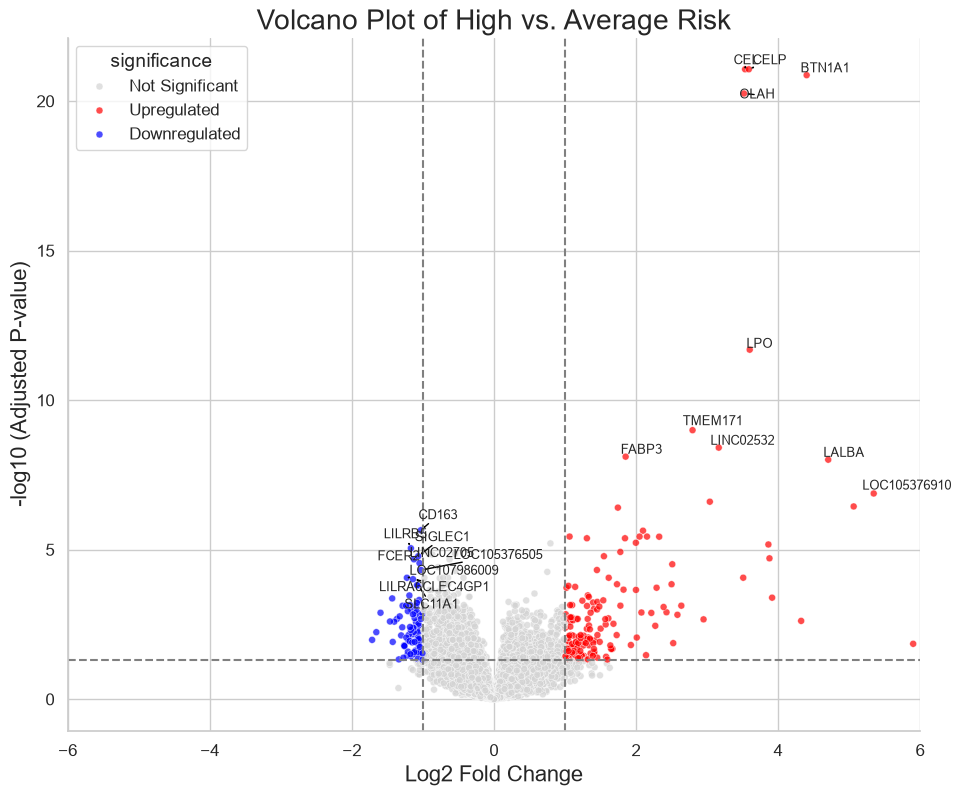

In [6]:
# --- 2. Volcano Plot ---
print("\n--- Generating Centered Volcano Plot ---")

# Prepare data for plotting
results_df['-log10(padj)'] = -np.log10(results_df['padj'])
# Replace infinite values that can result from log10(0)
results_df.replace([np.inf, -np.inf], np.nan, inplace=True)
results_df.dropna(subset=['-log10(padj)'], inplace=True)

# Assign significance categories for coloring
results_df['significance'] = 'Not Significant'
results_df.loc[(results_df['padj'] < padj_thresh) & (results_df['log2FoldChange'] > log2fc_thresh), 'significance'] = 'Upregulated'
results_df.loc[(results_df['padj'] < padj_thresh) & (results_df['log2FoldChange'] < -log2fc_thresh), 'significance'] = 'Downregulated'

# Select top genes for annotation to avoid clutter
top_upregulated = results_df[results_df['significance'] == 'Upregulated'].sort_values('padj').head(10)
top_downregulated = results_df[results_df['significance'] == 'Downregulated'].sort_values('padj').head(10)
genes_to_annotate = pd.concat([top_upregulated, top_downregulated])

# Create the plot
plt.figure(figsize=(11, 9))
volcano_palette = {'Upregulated': 'red', 'Downregulated': 'blue', 'Not Significant': 'lightgrey'}
ax_volcano = sns.scatterplot(
    data=results_df, x='log2FoldChange', y='-log10(padj)',
    hue='significance', palette=volcano_palette,
    s=25, alpha=0.7, legend='full'
)

# Add threshold lines
ax_volcano.axvline(x=log2fc_thresh, color='grey', linestyle='--')
ax_volcano.axvline(x=-log2fc_thresh, color='grey', linestyle='--')
ax_volcano.axhline(y=-np.log10(padj_thresh), color='grey', linestyle='--')

# Add gene labels
texts = []
for idx, row in genes_to_annotate.iterrows():
    texts.append(plt.text(row['log2FoldChange'], row['-log10(padj)'], idx, fontsize=9))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

# **Center the x-axis for a symmetric appearance**
limit = np.ceil(results_df['log2FoldChange'].abs().max())
ax_volcano.set_xlim(-limit, limit)

ax_volcano.set_title('Volcano Plot of High vs. Average Risk')
ax_volcano.set_xlabel('Log2 Fold Change')
ax_volcano.set_ylabel('-log10 (Adjusted P-value)')
sns.despine()
_savefig("volcano_plot.png")
plt.show()


--- Generating Clustered Heatmap ---
[saved] output\heatmap_deg_clustermap.png


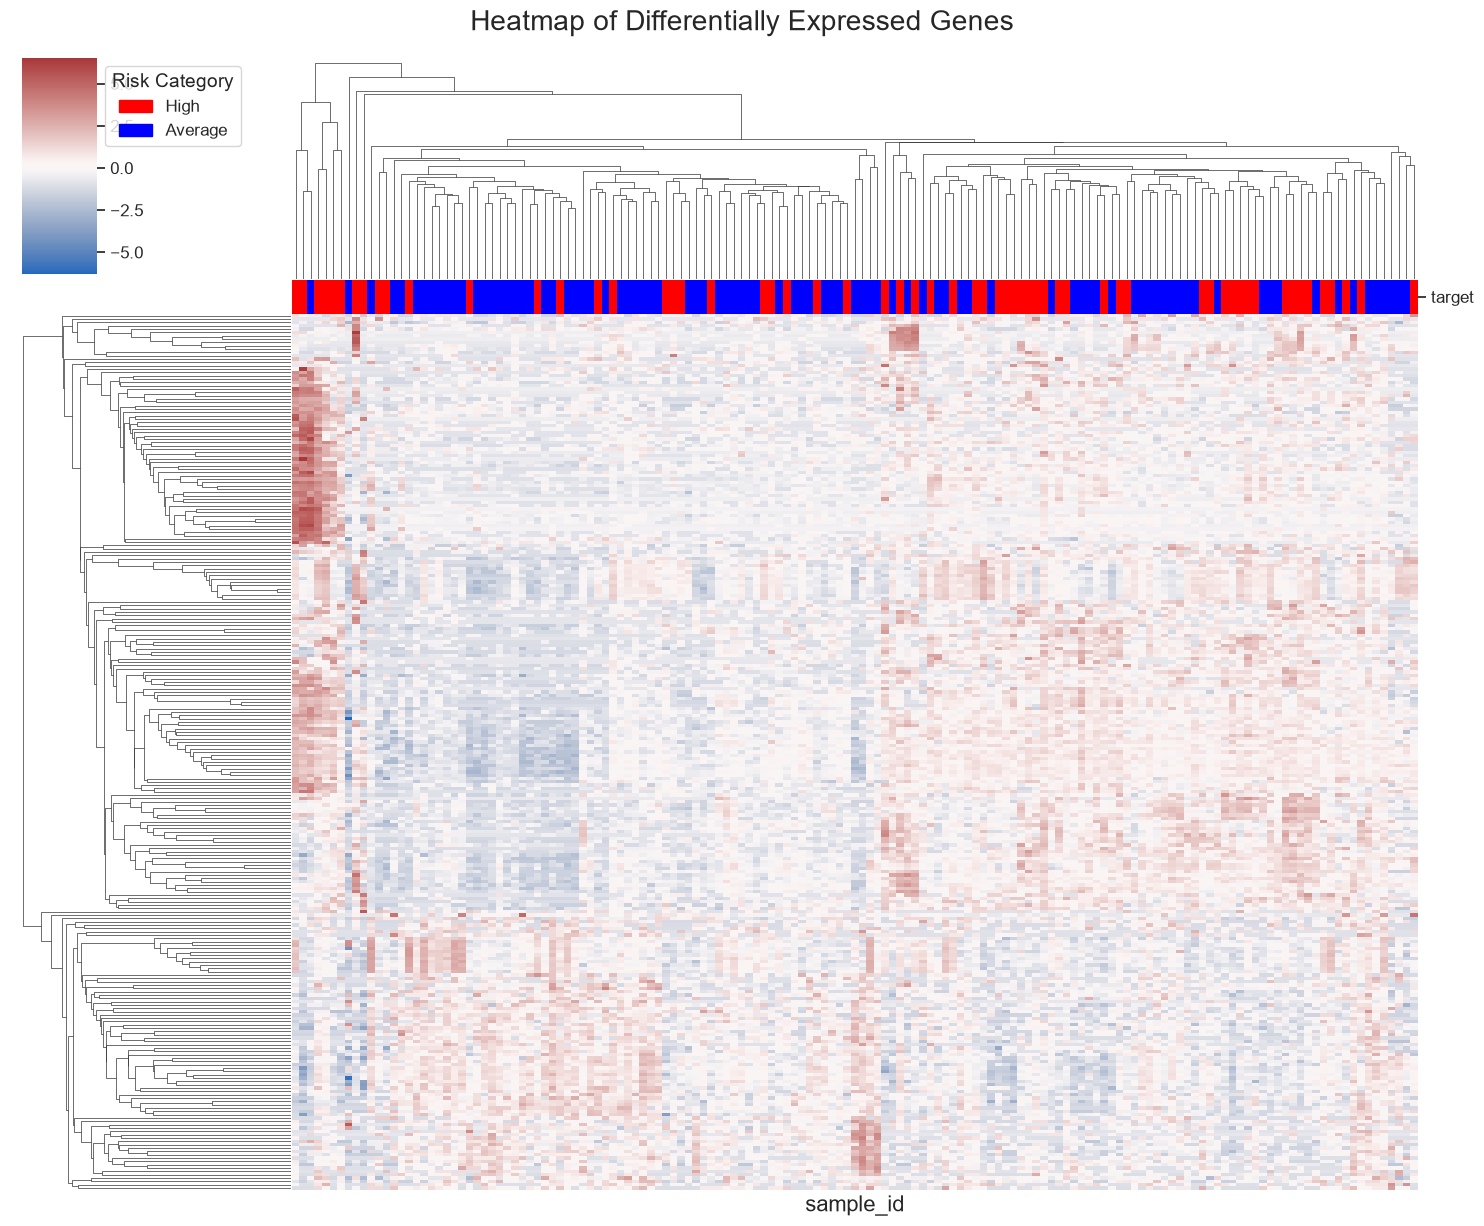

In [7]:
# --- 3. Clustered Heatmap ---
print("\n--- Generating Clustered Heatmap ---")
#from scipy.stats import zscore

# Select log-transformed data for significant genes
heatmap_data = X_log_transformed[significant_genes]

# Apply Z-score scaling across samples (rows) for each gene (column)
# We transpose (.T) so genes are rows, scale, then transpose back.
heatmap_data_zscored = heatmap_data.apply(zscore, axis=0)

# Create color mapping for the sample annotation bar
risk_categories = y.map({1: 'High', 0: 'Average'})
col_colors = risk_categories.map(palette)

# Create the clustermap
# Note: Depending on the number of genes, this can be computationally intensive
g = sns.clustermap(
    heatmap_data_zscored.T,  # Transpose so genes are rows, samples are columns
    cmap='vlag',             # A diverging colormap is good for Z-scores (blue-white-red)
    col_colors=col_colors,   # Add the risk category annotation bar
    figsize=(15, 12),
    yticklabels=False,       # Hide gene names on y-axis to avoid clutter
    xticklabels=False        # Hide sample names on x-axis
)
g.fig.suptitle('Heatmap of Differentially Expressed Genes', fontsize=20, y=1.02)

# Create a custom legend for the annotation bar
handles = [plt.Rectangle((0,0),1,1, color=color) for color in palette.values()]
plt.legend(handles, palette.keys(), title='Risk Category', bbox_to_anchor=(1, 1), loc='upper left')
g.fig.savefig(OUT_DIR / "heatmap_deg_clustermap.png", dpi=300, bbox_inches="tight")  # 新增
print(f"[saved] {OUT_DIR / 'heatmap_deg_clustermap.png'}")
plt.show()